In [2]:
!pip -q install --no-cache-dir pandas numpy scipy scikit-learn matplotlib seaborn
!pip -q install --no-cache-dir torch torch-geometric
!pip -q install --no-cache-dir tensorflow==2.19.1 tf-keras

In [3]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import random
from pathlib import Path
from copy import deepcopy

import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    auc,
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data, HeteroData
from torch_geometric.nn import GCNConv, GATConv, HANConv

import tensorflow as tf

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("PyTorch:", torch.__version__)
print("TensorFlow:", tf.__version__)

NumPy: 2.0.2
Pandas: 2.2.2
PyTorch: 2.10.0+cpu
TensorFlow: 2.19.1


In [4]:
DATA_DIR = Path.cwd()  # put elliptic_txs_*.csv here
REPO_DIR = Path.cwd() / "DGFraud-TF2"

if not REPO_DIR.exists():
    print("Cloning DGFraud-TF2 ...")
    !git clone https://github.com/safe-graph/DGFraud-TF2.git

import sys
if str(REPO_DIR) not in sys.path:
    sys.path.append(str(REPO_DIR))

print("DATA_DIR:", DATA_DIR)
print("REPO_DIR:", REPO_DIR)
print("Data files found:",
      (DATA_DIR / "elliptic_txs_features.csv").exists(),
      (DATA_DIR / "elliptic_txs_edgelist.csv").exists(),
      (DATA_DIR / "elliptic_txs_classes.csv").exists())

Cloning DGFraud-TF2 ...
Cloning into 'DGFraud-TF2'...
remote: Enumerating objects: 441, done.
remote: Counting objects: 100% (130/130), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 441 (delta 118), reused 110 (delta 110), pack-reused 311 (from 1)
Receiving objects: 100% (441/441), 30.58 MiB | 26.40 MiB/s, done.
Resolving deltas: 100% (210/210), done.
DATA_DIR: /content
REPO_DIR: /content/DGFraud-TF2
Data files found: True True True


In [5]:
cd DGFraud-TF2

/content/DGFraud-TF2


In [6]:
SEED = 42
SAMPLE_SIZE = 3000
TRAIN_SIZE = 0.60
VAL_SIZE = 0.20
TEST_SIZE = 0.20

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
tf.random.set_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

def load_elliptic_common(data_dir: Path, sample_size: int = 3000, seed: int = 42):
    features_df = pd.read_csv("elliptic_txs_features.csv", header=None)
    edges_df = pd.read_csv("elliptic_txs_edgelist.csv")
    classes_df = pd.read_csv("elliptic_txs_classes.csv")

    # feature matrix
    tx_ids_all = features_df[0].astype(int).values
    X_all = features_df.iloc[:, 2:].astype(float).values
    X_all[np.isinf(X_all)] = np.nan
    X_all = np.nan_to_num(X_all, nan=0.0)

    scaler = StandardScaler()
    X_all = scaler.fit_transform(X_all)
    X_all = np.nan_to_num(X_all, nan=0.0).astype(np.float32)

    # labels
    classes_df = classes_df.copy()
    classes_df["class"] = classes_df["class"].astype(str)
    classes_df = classes_df[classes_df["class"].isin(["1", "2"])].copy()
    classes_df["class"] = classes_df["class"].map({"1": 1, "2": 0}).astype(int)

    label_map = dict(zip(classes_df["txId"].astype(int), classes_df["class"].astype(int)))
    y_all = np.array([label_map.get(tx, -1) for tx in tx_ids_all], dtype=np.int64)

    labeled_mask = y_all != -1
    tx_ids = tx_ids_all[labeled_mask]
    X = X_all[labeled_mask]
    y = y_all[labeled_mask]

    if sample_size < len(y):
        sample_idx, _ = train_test_split(
            np.arange(len(y)),
            train_size=sample_size,
            stratify=y,
            random_state=seed,
        )
        sample_idx = np.array(sample_idx, dtype=np.int64)
    else:
        sample_idx = np.arange(len(y), dtype=np.int64)

    tx_ids = tx_ids[sample_idx]
    X = X[sample_idx]
    y = y[sample_idx]

    txid_to_idx = {int(tx): i for i, tx in enumerate(tx_ids)}

    edges_df = edges_df.copy()
    edges_df["txId1"] = edges_df["txId1"].astype(int)
    edges_df["txId2"] = edges_df["txId2"].astype(int)

    src_idx = edges_df["txId1"].map(txid_to_idx)
    dst_idx = edges_df["txId2"].map(txid_to_idx)
    valid = (~src_idx.isna()) & (~dst_idx.isna())

    edge_pairs = np.vstack([
        src_idx[valid].astype(int).values,
        dst_idx[valid].astype(int).values,
    ])

    rev_pairs = edge_pairs[::-1]
    edge_pairs = np.concatenate([edge_pairs, rev_pairs], axis=1)

    edge_index = torch.tensor(edge_pairs, dtype=torch.long)

    n = len(y)
    adj = sp.coo_matrix(
        (np.ones(edge_index.shape[1], dtype=np.float32),
         (edge_index[0].numpy(), edge_index[1].numpy())),
        shape=(n, n),
        dtype=np.float32,
    ).tocsr()
    adj.setdiag(0)
    adj.eliminate_zeros()

    return {
        "X": X.astype(np.float32),
        "y": y.astype(np.int64),
        "tx_ids": tx_ids,
        "edge_index": edge_index,
        "adj": adj,
        "dataframes": (features_df, edges_df, classes_df),
    }

base = load_elliptic_common(DATA_DIR, sample_size=SAMPLE_SIZE, seed=SEED)
X = base["X"]
y = base["y"]
edge_index = base["edge_index"]
adj = base["adj"]

print("Common sample shape:", X.shape, y.shape)
print("Edge index shape:", edge_index.shape)
print("Adj shape:", adj.shape)
print("Class balance:", np.bincount(y))

Device: cpu
Common sample shape: (3000, 165) (3000,)
Edge index shape: torch.Size([2, 324])
Adj shape: (3000, 3000)
Class balance: [2707  293]


In [7]:
def make_splits(y_arr, seed=42):
    idx = np.arange(len(y_arr))
    train_idx, temp_idx = train_test_split(
        idx, train_size=TRAIN_SIZE, stratify=y_arr, random_state=seed
    )
    val_idx, test_idx = train_test_split(
        temp_idx, test_size=0.5, stratify=y_arr[temp_idx], random_state=seed
    )
    return np.array(train_idx), np.array(val_idx), np.array(test_idx)

train_idx, val_idx, test_idx = make_splits(y, SEED)
print("Split sizes:", len(train_idx), len(val_idx), len(test_idx))

def build_masks(n, train_idx, val_idx, test_idx):
    train_mask = torch.zeros(n, dtype=torch.bool)
    val_mask = torch.zeros(n, dtype=torch.bool)
    test_mask = torch.zeros(n, dtype=torch.bool)
    train_mask[train_idx] = True
    val_mask[val_idx] = True
    test_mask[test_idx] = True
    return train_mask, val_mask, test_mask

train_mask, val_mask, test_mask = build_masks(len(y), train_idx, val_idx, test_idx)

def tune_threshold(y_true, probs, grid=None):
    if grid is None:
        grid = np.linspace(0.05, 0.95, 91)
    best_t = 0.5
    best_f1 = -1.0
    for t in grid:
        pred = (probs >= t).astype(int)
        score = f1_score(y_true, pred, zero_division=0)
        if score > best_f1:
            best_f1 = score
            best_t = float(t)
    return best_t, best_f1

def compute_metrics(y_true, probs, threshold=0.5):
    pred = (probs >= threshold).astype(int)
    out = {
        "accuracy": accuracy_score(y_true, pred),
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0),
        "f1": f1_score(y_true, pred, zero_division=0),
        "pr_auc": average_precision_score(y_true, probs),
    }
    try:
        out["roc_auc"] = roc_auc_score(y_true, probs)
    except Exception:
        out["roc_auc"] = np.nan
    cm = confusion_matrix(y_true, pred, labels=[0, 1])
    out["tn"], out["fp"], out["fn"], out["tp"] = cm.ravel()
    out["threshold"] = threshold
    return out

def probs_from_logits(logits):
    return F.softmax(logits, dim=1)[:, 1].detach().cpu().numpy()

def plot_confusion(cm, title):
    plt.figure(figsize=(4.8, 4))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["Pred licit", "Pred illicit"],
        yticklabels=["True licit", "True illicit"]
    )
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_model_comparison(results_df):
    metrics = ["f1", "precision", "recall", "pr_auc", "roc_auc", "accuracy"]
    plot_df = results_df.set_index("model")[metrics]
    ax = plot_df.plot(kind="bar", figsize=(12, 5))
    ax.set_title("Model comparison on the same Elliptic subgraph")
    ax.set_xlabel("Model")
    ax.set_ylabel("Score")
    ax.legend(loc="best", ncol=3)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

Split sizes: 1800 600 600


In [8]:
x_torch = torch.tensor(X, dtype=torch.float32)
y_torch = torch.tensor(y, dtype=torch.long)

pyg_data = Data(x=x_torch, edge_index=edge_index, y=y_torch)

print(pyg_data)
print("num_nodes:", pyg_data.num_nodes)
print("num_edges:", pyg_data.num_edges)

Data(x=[3000, 165], edge_index=[2, 324], y=[3000])
num_nodes: 3000
num_edges: 324


/tmp/ipykernel_1023/3694877083.py:60: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  f"epoch {epoch+1:03d} | loss={float(loss):.4f} "


epoch 010 | loss=0.2232 val_pr_auc=0.6762 val_f1@0.5=0.5445
epoch 020 | loss=0.1389 val_pr_auc=0.6854 val_f1@0.5=0.6623
epoch 030 | loss=0.0912 val_pr_auc=0.7551 val_f1@0.5=0.6803
epoch 040 | loss=0.0653 val_pr_auc=0.7727 val_f1@0.5=0.6993
epoch 050 | loss=0.0486 val_pr_auc=0.7881 val_f1@0.5=0.7153
epoch 060 | loss=0.0379 val_pr_auc=0.7932 val_f1@0.5=0.7121
epoch 070 | loss=0.0306 val_pr_auc=0.7950 val_f1@0.5=0.7344
epoch 080 | loss=0.0254 val_pr_auc=0.8042 val_f1@0.5=0.7402
GCN metrics: {'accuracy': 0.975, 'precision': 0.9574468085106383, 'recall': 0.7758620689655172, 'f1': 0.8571428571428571, 'pr_auc': np.float64(0.8814078264728056), 'roc_auc': np.float64(0.9708614327522586), 'tn': np.int64(540), 'fp': np.int64(2), 'fn': np.int64(13), 'tp': np.int64(45), 'threshold': 0.95, 'best_val_pr_auc': 0.804170275670013, 'best_val_f1': 0.8113207547169812}
              precision    recall  f1-score   support

           0     0.9765    0.9963    0.9863       542
           1     0.9574    0.775

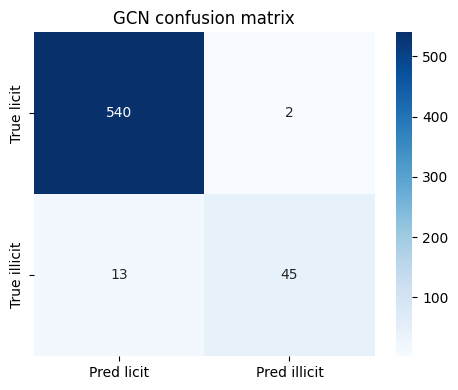

In [9]:
class GCN(nn.Module):
    def __init__(self, in_channels, hidden_channels=64, out_channels=2):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        return x

def train_torch_node_classifier(
    model, data, train_mask, val_mask, test_mask,
    lr=0.005, weight_decay=5e-4, epochs=80, patience=15,
):
    device = next(model.parameters()).device
    data = data.to(device)
    train_mask = train_mask.to(device)
    val_mask = val_mask.to(device)
    test_mask = test_mask.to(device)

    y_train = data.y[train_mask].detach().cpu().numpy()
    class_weights = compute_class_weight(class_weight="balanced", classes=np.array([0, 1]), y=y_train)
    class_weights = torch.tensor(class_weights, dtype=torch.float32, device=device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_state = deepcopy(model.state_dict())
    best_val_score = -1.0
    best_val_probs = None
    wait = 0

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        logits = model(data.x, data.edge_index)
        loss = F.cross_entropy(logits[train_mask], data.y[train_mask], weight=class_weights)
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            val_logits = model(data.x, data.edge_index)[val_mask]
            val_probs = probs_from_logits(val_logits)
            y_val = data.y[val_mask].detach().cpu().numpy()
            val_pr_auc = average_precision_score(y_val, val_probs)

        if val_pr_auc > best_val_score:
            best_val_score = val_pr_auc
            best_state = deepcopy(model.state_dict())
            best_val_probs = val_probs.copy()
            wait = 0
        else:
            wait += 1

        if (epoch + 1) % 10 == 0:
            y_val_pred = (val_probs >= 0.5).astype(int)
            print(
                f"epoch {epoch+1:03d} | loss={float(loss):.4f} "
                f"val_pr_auc={val_pr_auc:.4f} val_f1@0.5={f1_score(y_val, y_val_pred, zero_division=0):.4f}"
            )

        if wait >= patience:
            print("Early stopping.")
            break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        test_logits = model(data.x, data.edge_index)[test_mask]
        test_probs = probs_from_logits(test_logits)
        y_test = data.y[test_mask].detach().cpu().numpy()

    best_thr, best_val_f1 = tune_threshold(data.y[val_mask].detach().cpu().numpy(), best_val_probs)
    metrics = compute_metrics(y_test, test_probs, threshold=best_thr)
    metrics["best_val_pr_auc"] = float(best_val_score)
    metrics["best_val_f1"] = float(best_val_f1)

    return model, metrics, y_test, test_probs, best_thr

gcn = GCN(in_channels=pyg_data.num_node_features, hidden_channels=64, out_channels=2).to(device)
gcn, gcn_metrics, y_test_gcn, p_test_gcn, thr_gcn = train_torch_node_classifier(
    gcn, pyg_data, train_mask, val_mask, test_mask,
    lr=0.005, weight_decay=5e-4, epochs=80, patience=15
)

print("GCN metrics:", gcn_metrics)
print(classification_report(y_test_gcn, (p_test_gcn >= thr_gcn).astype(int), digits=4, zero_division=0))
plot_confusion(np.array([[gcn_metrics["tn"], gcn_metrics["fp"]], [gcn_metrics["fn"], gcn_metrics["tp"]]]), "GCN confusion matrix")

epoch 010 | loss=1.5142 val_pr_auc=0.2221 val_f1@0.5=0.3291
epoch 020 | loss=1.0666 val_pr_auc=0.3754 val_f1@0.5=0.3475
epoch 030 | loss=0.9371 val_pr_auc=0.4366 val_f1@0.5=0.4000
epoch 040 | loss=0.8835 val_pr_auc=0.4472 val_f1@0.5=0.4228
epoch 050 | loss=0.7562 val_pr_auc=0.4654 val_f1@0.5=0.4407
epoch 060 | loss=0.6926 val_pr_auc=0.4774 val_f1@0.5=0.4280
epoch 070 | loss=0.7333 val_pr_auc=0.5011 val_f1@0.5=0.4426
epoch 080 | loss=0.6654 val_pr_auc=0.5335 val_f1@0.5=0.4541
GAT metrics: {'accuracy': 0.9233333333333333, 'precision': 0.581081081081081, 'recall': 0.7413793103448276, 'f1': 0.6515151515151515, 'pr_auc': np.float64(0.6999450949621931), 'roc_auc': np.float64(0.9534610001272427), 'tn': np.int64(511), 'fp': np.int64(31), 'fn': np.int64(15), 'tp': np.int64(43), 'threshold': 0.8799999999999999, 'best_val_pr_auc': 0.5335442454558408, 'best_val_f1': 0.656934306569343}
              precision    recall  f1-score   support

           0     0.9715    0.9428    0.9569       542
     

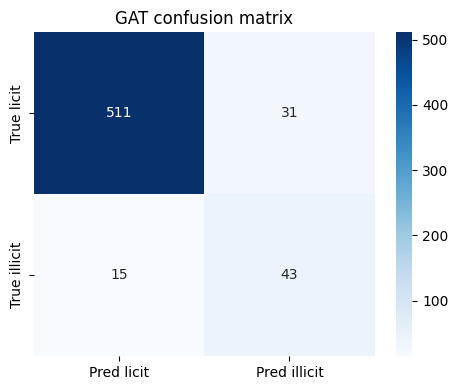

In [10]:
class GAT(nn.Module):
    def __init__(self, in_channels, hidden_channels=8, out_channels=2, heads=8):
        super().__init__()
        self.gat1 = GATConv(in_channels, hidden_channels, heads=heads, dropout=0.3)
        self.gat2 = GATConv(hidden_channels * heads, out_channels, heads=1, concat=False, dropout=0.3)

    def forward(self, x, edge_index):
        x = F.dropout(x, p=0.6, training=self.training)
        x = self.gat1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=0.6, training=self.training)
        x = self.gat2(x, edge_index)
        return x

gat = GAT(in_channels=pyg_data.num_node_features, hidden_channels=8, out_channels=2, heads=8).to(device)
gat, gat_metrics, y_test_gat, p_test_gat, thr_gat = train_torch_node_classifier(
    gat, pyg_data, train_mask, val_mask, test_mask,
    lr=0.001, weight_decay=5e-4, epochs=80, patience=15
)

print("GAT metrics:", gat_metrics)
print(classification_report(y_test_gat, (p_test_gat >= thr_gat).astype(int), digits=4, zero_division=0))
plot_confusion(np.array([[gat_metrics["tn"], gat_metrics["fp"]], [gat_metrics["fn"], gat_metrics["tp"]]]), "GAT confusion matrix")

epoch 020 | loss=0.6440 val_pr_auc=0.1039 val_f1@0.5=0.1878
epoch 040 | loss=0.6407 val_pr_auc=0.1039 val_f1@0.5=0.1878
Early stopping.
HAN metrics: {'accuracy': 0.18833333333333332, 'precision': 0.10351201478743069, 'recall': 0.9655172413793104, 'f1': 0.18697829716193656, 'pr_auc': np.float64(0.15002720511558695), 'roc_auc': np.float64(0.5591519277261738), 'tn': np.int64(57), 'fp': np.int64(485), 'fn': np.int64(2), 'tp': np.int64(56), 'threshold': 0.30999999999999994, 'best_val_pr_auc': 0.10394643280817248, 'best_val_f1': 0.18780889621087316}
              precision    recall  f1-score   support

           0     0.9661    0.1052    0.1897       542
           1     0.1035    0.9655    0.1870        58

    accuracy                         0.1883       600
   macro avg     0.5348    0.5353    0.1883       600
weighted avg     0.8827    0.1883    0.1894       600



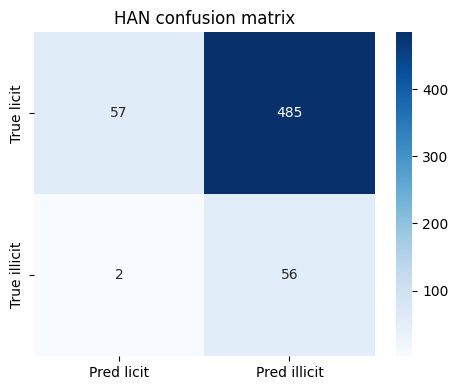

In [11]:
hetero = HeteroData()
hetero["tx"].x = x_torch.clone()
hetero["tx"].y = y_torch.clone()
hetero["tx"].train_mask = train_mask.clone()
hetero["tx"].val_mask = val_mask.clone()
hetero["tx"].test_mask = test_mask.clone()
hetero["tx", "interact", "tx"].edge_index = edge_index.clone()

class HANModel(nn.Module):
    def __init__(self, in_channels, hidden_channels=128, out_channels=2, heads=4, dropout=0.5, metadata=None):
        super().__init__()
        self.han = HANConv(
            in_channels=in_channels,
            out_channels=hidden_channels,
            heads=heads,
            metadata=metadata,
        )
        self.lin = nn.Linear(hidden_channels, out_channels)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x_dict, edge_index_dict):
        x_dict = self.han(x_dict, edge_index_dict)
        x = F.relu(x_dict["tx"])
        x = self.dropout(x)
        x = self.lin(x)
        return x

def train_han(model, hetero_data, lr=0.005, epochs=120, patience=15):
    device = next(model.parameters()).device
    hetero_data = hetero_data.to(device)

    y_train = hetero_data["tx"].y[hetero_data["tx"].train_mask].detach().cpu().numpy()
    class_weights = compute_class_weight(class_weight="balanced", classes=np.array([0, 1]), y=y_train)
    class_weights = torch.tensor(class_weights, dtype=torch.float32, device=device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_state = deepcopy(model.state_dict())
    best_val_score = -1.0
    best_val_probs = None
    wait = 0

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        out = model(hetero_data.x_dict, hetero_data.edge_index_dict)
        loss = F.cross_entropy(out[hetero_data["tx"].train_mask], hetero_data["tx"].y[hetero_data["tx"].train_mask], weight=class_weights)
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            out_val = model(hetero_data.x_dict, hetero_data.edge_index_dict)[hetero_data["tx"].val_mask]
            val_probs = probs_from_logits(out_val)
            y_val = hetero_data["tx"].y[hetero_data["tx"].val_mask].detach().cpu().numpy()
            val_pr_auc = average_precision_score(y_val, val_probs)

        if val_pr_auc > best_val_score:
            best_val_score = val_pr_auc
            best_state = deepcopy(model.state_dict())
            best_val_probs = val_probs.copy()
            wait = 0
        else:
            wait += 1

        if (epoch + 1) % 20 == 0:
            y_val_pred = (val_probs >= 0.5).astype(int)
            print(
                f"epoch {epoch+1:03d} | loss={float(loss):.4f} "
                f"val_pr_auc={val_pr_auc:.4f} val_f1@0.5={f1_score(y_val, y_val_pred, zero_division=0):.4f}"
            )

        if wait >= patience:
            print("Early stopping.")
            break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        test_logits = model(hetero_data.x_dict, hetero_data.edge_index_dict)[hetero_data["tx"].test_mask]
        test_probs = probs_from_logits(test_logits)
        y_test = hetero_data["tx"].y[hetero_data["tx"].test_mask].detach().cpu().numpy()

    best_thr, best_val_f1 = tune_threshold(
        hetero_data["tx"].y[hetero_data["tx"].val_mask].detach().cpu().numpy(),
        best_val_probs
    )
    metrics = compute_metrics(y_test, test_probs, threshold=best_thr)
    metrics["best_val_pr_auc"] = float(best_val_score)
    metrics["best_val_f1"] = float(best_val_f1)
    return model, metrics, y_test, test_probs, best_thr

han = HANModel(
    in_channels=x_torch.shape[1],
    hidden_channels=128,
    out_channels=2,
    heads=4,
    dropout=0.5,
    metadata=hetero.metadata(),
).to(device)

han, han_metrics, y_test_han, p_test_han, thr_han = train_han(
    han, hetero, lr=0.005, epochs=120, patience=15
)

print("HAN metrics:", han_metrics)
print(classification_report(y_test_han, (p_test_han >= thr_han).astype(int), digits=4, zero_division=0))
plot_confusion(np.array([[han_metrics["tn"], han_metrics["fp"]], [han_metrics["fn"], han_metrics["tp"]]]), "HAN confusion matrix")

/usr/local/lib/python3.12/dist-packages/tf_keras/src/initializers/initializers.py:121: UserWarning: The initializer GlorotUniform is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(


Trainable vars: 8
epoch 010 | loss=0.6839 acc=0.9022 | val_pr_auc=0.0897 val_f0.5=0.1200 thr=0.10 precision=0.0983 recall=1.0000
epoch 020 | loss=0.6747 acc=0.9022 | val_pr_auc=0.0953 val_f0.5=0.1200 thr=0.10 precision=0.0983 recall=1.0000
Early stopping.
SemiGNN metrics: {'accuracy': 0.16166666666666665, 'precision': 0.0990990990990991, 'recall': 0.9482758620689655, 'f1': 0.17944535073409462, 'roc_auc': np.float64(0.5049942740806719), 'pr_auc': np.float64(0.10017633100230935), 'tn': 42, 'fp': 500, 'fn': 3, 'tp': 55, 'best_val_pr_auc': -1.0, 'best_val_f1': 0.12392969806206076, 'best_thr': 0.49}
              precision    recall  f1-score   support

           0     0.9333    0.0775    0.1431       542
           1     0.0991    0.9483    0.1794        58

    accuracy                         0.1617       600
   macro avg     0.5162    0.5129    0.1613       600
weighted avg     0.8527    0.1617    0.1466       600



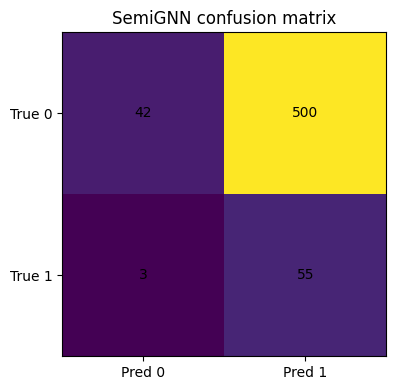

In [16]:
!pip -q install --no-cache-dir tf-keras

import numpy as np
import scipy.sparse as sp
import tensorflow as tf

from copy import deepcopy
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    accuracy_score,
)

from algorithms.SemiGNN.SemiGNN import SemiGNN

tf.keras.backend.clear_session()

# ---------------------------------------------------------
# helpers
# ---------------------------------------------------------
def to_binary_labels(y_arr):
    y_arr = np.asarray(y_arr).reshape(-1)
    uniq = sorted(np.unique(y_arr).tolist())

    # Elliptic often uses 1 / 2
    if set(uniq) == {1, 2}:
        return np.where(y_arr == 1, 1, 0).astype(np.int32)

    # already 0 / 1
    if set(uniq) <= {0, 1}:
        return y_arr.astype(np.int32)

    # fallback
    mapping = {uniq[0]: 0, uniq[-1]: 1}
    return np.vectorize(mapping.get)(y_arr).astype(np.int32)

def build_tf_splits(y_arr, seed=42):
    idx = np.arange(len(y_arr))
    train_idx, temp_idx = train_test_split(
        idx, train_size=TRAIN_SIZE, stratify=y_arr, random_state=seed
    )
    val_idx, test_idx = train_test_split(
        temp_idx, test_size=0.5, stratify=y_arr[temp_idx], random_state=seed
    )
    return train_idx.astype(np.int32), val_idx.astype(np.int32), test_idx.astype(np.int32)

def tune_threshold(y_true, probs, min_precision=0.20, beta=0.5):
    """
    Select threshold on validation set with a precision constraint.
    beta=0.5 -> F0.5, more weight on precision than recall.
    """
    best_thr = 0.5
    best_score = -1.0

    for thr in np.linspace(0.10, 0.95, 86):
        pred = (probs >= thr).astype(int)

        prec = precision_score(y_true, pred, zero_division=0)
        rec = recall_score(y_true, pred, zero_division=0)

        if prec < min_precision:
            continue

        score = (1 + beta**2) * prec * rec / (beta**2 * prec + rec + 1e-12)

        if score > best_score:
            best_score = score
            best_thr = float(thr)

    # fallback: if no threshold satisfies precision constraint
    if best_score < 0:
        best_thr = 0.5
        best_score = -1.0
        for thr in np.linspace(0.10, 0.95, 86):
            pred = (probs >= thr).astype(int)
            prec = precision_score(y_true, pred, zero_division=0)
            rec = recall_score(y_true, pred, zero_division=0)
            score = (1 + beta**2) * prec * rec / (beta**2 * prec + rec + 1e-12)
            if score > best_score:
                best_score = score
                best_thr = float(thr)

    return best_thr, best_score

def compute_metrics(y_true, probs, threshold=0.5):
    pred = (probs >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()

    out = {
        "accuracy": accuracy_score(y_true, pred),
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0),
        "f1": f1_score(y_true, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, probs) if len(np.unique(y_true)) > 1 else np.nan,
        "pr_auc": average_precision_score(y_true, probs) if len(np.unique(y_true)) > 1 else np.nan,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }
    return out

def plot_confusion(cm, title):
    import matplotlib.pyplot as plt

    plt.figure(figsize=(4.5, 4))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.xticks([0, 1], ["Pred 0", "Pred 1"])
    plt.yticks([0, 1], ["True 0", "True 1"])
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center")
    plt.tight_layout()
    plt.show()

def semi_logits(model, adj_data_tf, idx_mask):
    """
    Extract logits from the original SemiGNN internals.
    """
    h1 = []
    for v in range(model.view_num):
        h = model.node_att_layer[v]([model.emb, adj_data_tf[v]])
        h = tf.reshape(h, [model.nodes, model.init_emb_size])
        h1.append(h)

    h1 = tf.concat(h1, axis=0)
    h1 = tf.reshape(h1, [model.view_num, model.nodes, model.init_emb_size])

    h2 = model.view_att_layer(h1)
    a_u = model.olp(h2)

    masked_data = tf.gather(a_u, idx_mask)
    logits = tf.matmul(masked_data, model.theta)
    return logits

def semi_forward(model, adj_data_tf, labels_onehot, idx_mask, class_weight_vec):
    logits = semi_logits(model, adj_data_tf, idx_mask)
    masked_label = tf.gather(labels_onehot, idx_mask)

    ce = tf.nn.softmax_cross_entropy_with_logits(labels=masked_label, logits=logits)
    sample_weights = tf.reduce_sum(masked_label * class_weight_vec, axis=1)
    loss = tf.reduce_mean(ce * sample_weights)

    probs = tf.nn.softmax(logits, axis=1)
    pred = tf.argmax(probs, axis=1, output_type=tf.int32)
    true = tf.argmax(masked_label, axis=1, output_type=tf.int32)
    acc = tf.reduce_mean(tf.cast(tf.equal(pred, true), tf.float32))
    return loss, acc, probs

# ---------------------------------------------------------
# data prep (only for SemiGNN section)
# ---------------------------------------------------------
y_bin = to_binary_labels(y)

semi_train_idx, semi_val_idx, semi_test_idx = build_tf_splits(y_bin, SEED)

adj_semi = adj.copy().astype(np.float32)
if sp.issparse(adj_semi):
    adj_semi = adj_semi + sp.eye(adj_semi.shape[0], format="csr", dtype=np.float32)
    adj_dense = adj_semi.toarray().astype(np.float32)
else:
    adj_dense = np.asarray(adj_semi, dtype=np.float32)
    np.fill_diagonal(adj_dense, 1.0)

labels_onehot = tf.convert_to_tensor(
    tf.keras.utils.to_categorical(y_bin, num_classes=2).astype(np.float32),
    dtype=tf.float32
)
adj_tf = tf.convert_to_tensor(adj_dense, dtype=tf.float32)

# ---------------------------------------------------------
# args
# ---------------------------------------------------------
class SemiArgs:
    epochs = 80
    lr = 1e-3
    seed = 42
    init_emb_size = 4
    semi_encoding1 = 3
    semi_encoding2 = 2
    semi_encoding3 = 4
    alpha = 0.7
    patience = 10

args = SemiArgs()

np.random.seed(args.seed)
tf.random.set_seed(args.seed)

num_classes = 2
num_nodes = len(y_bin)

y_train = y_bin[semi_train_idx]
cw = compute_class_weight(class_weight="balanced", classes=np.array([0, 1]), y=y_train)
cw_map = {int(c): float(w) for c, w in zip([0, 1], cw)}

# clamp minority weight a bit to reduce FP
class_weight_vec = tf.constant([1.0, 1.0], dtype=tf.float32)

# one view only
adj_data_tf = [adj_tf]

# ---------------------------------------------------------
# model
# ---------------------------------------------------------
semi_model = SemiGNN(
    num_nodes,
    num_classes,
    args.semi_encoding1,
    args.semi_encoding2,
    args.semi_encoding3,
    args.init_emb_size,
    1,              # view_num
    args.alpha
)

optimizer = tf.keras.optimizers.Adam(learning_rate=args.lr)

# warm-up forward pass -> builds model internals
_ = semi_forward(
    semi_model, adj_data_tf, labels_onehot, semi_train_idx, class_weight_vec
)

# IMPORTANT:
# do NOT use semi_model.trainable_variables here if model-level built flag is flaky
train_vars = []
for layer in semi_model.layers:
    train_vars.extend(layer.trainable_variables)

print("Trainable vars:", len(train_vars))

best_state = None
best_val_probs = None
best_thr = 0.5
best_val_f1 = -1.0
wait = 0
best_score = -1.0

# ---------------------------------------------------------
# training
# ---------------------------------------------------------
for epoch in range(args.epochs):
    with tf.GradientTape() as tape:
        loss, acc, _ = semi_forward(
            semi_model, adj_data_tf, labels_onehot, semi_train_idx, class_weight_vec
        )

    grads = tape.gradient(loss, train_vars)
    grads_and_vars = [(g, v) for g, v in zip(grads, train_vars) if g is not None]
    optimizer.apply_gradients(grads_and_vars)

    # validation
    val_loss, val_acc, val_probs = semi_forward(
        semi_model, adj_data_tf, labels_onehot, semi_val_idx, class_weight_vec
    )
    val_prob_pos = val_probs.numpy()[:, 1]
    y_val = y_bin[semi_val_idx]

    val_thr, val_f1 = tune_threshold(y_val, val_prob_pos)
    val_pr_auc = average_precision_score(y_val, val_prob_pos)
    val_thr, val_f05 = tune_threshold(y_val, val_prob_pos, min_precision=0.20, beta=0.5)

    if (epoch + 1) % 10 == 0:
        y_val_pred = (val_prob_pos >= val_thr).astype(int)
        print(
            f"epoch {epoch+1:03d} | loss={float(loss):.4f} acc={float(acc):.4f} | "
            f"val_pr_auc={val_pr_auc:.4f} val_f0.5={val_f05:.4f} thr={val_thr:.2f} "
            f"precision={precision_score(y_val, y_val_pred, zero_division=0):.4f} "
            f"recall={recall_score(y_val, y_val_pred, zero_division=0):.4f}"
        )

    # сохраняем лучшую модель по F0.5, а не только по PR-AUC
    if val_f05 > best_score:
      best_score = val_f05
      best_thr = val_thr
      best_state = semi_model.get_weights()
      wait = 0
    else:
      wait += 1

    if wait >= args.patience:
      print("Early stopping.")
      break

if best_state is not None:
    semi_model.set_weights(best_state)

# ---------------------------------------------------------
# threshold on best validation probs
# ---------------------------------------------------------
if best_val_probs is None:
    _, _, val_probs = semi_forward(
        semi_model, adj_data_tf, labels_onehot, semi_val_idx, class_weight_vec
    )
    best_thr, best_val_f1 = tune_threshold(y_bin[semi_val_idx], val_probs.numpy()[:, 1])

# ---------------------------------------------------------
# test
# ---------------------------------------------------------
test_loss, test_acc, test_probs = semi_forward(
    semi_model, adj_data_tf, labels_onehot, semi_test_idx, class_weight_vec
)
test_prob_pos = test_probs.numpy()[:, 1]
y_test = y_bin[semi_test_idx]
y_pred = (test_prob_pos >= best_thr).astype(int)

semi_metrics = compute_metrics(y_test, test_prob_pos, threshold=best_thr)
semi_metrics["best_val_pr_auc"] = float(best_val_pr_auc)
semi_metrics["best_val_f1"] = float(best_val_f1)
semi_metrics["best_thr"] = float(best_thr)

print("SemiGNN metrics:", semi_metrics)
print(classification_report(y_test, y_pred, digits=4, zero_division=0))

plot_confusion(
    np.array([[semi_metrics["tn"], semi_metrics["fp"]],
              [semi_metrics["fn"], semi_metrics["tp"]]]),
    "SemiGNN confusion matrix"
)

In [17]:
results = [
    {"model": "GCN", **gcn_metrics},
    {"model": "GAT", **gat_metrics},
    {"model": "HAN", **han_metrics},
    {"model": "SemiGNN", **semi_metrics},
]

results_df = pd.DataFrame(results)

display_cols = [
    "model", "threshold", "accuracy", "precision", "recall", "f1", "pr_auc", "roc_auc",
    "tn", "fp", "fn", "tp", "best_val_pr_auc", "best_val_f1"
]
results_df = results_df[display_cols].sort_values(by="f1", ascending=False).reset_index(drop=True)
results_df

,model,threshold,accuracy,precision,recall,f1,pr_auc,roc_auc,tn,fp,fn,tp,best_val_pr_auc,best_val_f1
0,GCN,0.95,0.975000,0.957447,0.775862,0.857143,0.881408,0.970861,540,2,13,45,0.804170,0.811321
1,GAT,0.88,0.923333,0.581081,0.741379,0.651515,0.699945,0.953461,511,31,15,43,0.533544,0.656934
2,HAN,0.31,0.188333,0.103512,0.965517,0.186978,0.150027,0.559152,57,485,2,56,0.103946,0.187809
3,SemiGNN,NaN,0.161667,0.099099,0.948276,0.179445,0.100176,0.504994,42,500,3,55,-1.000000,0.123930


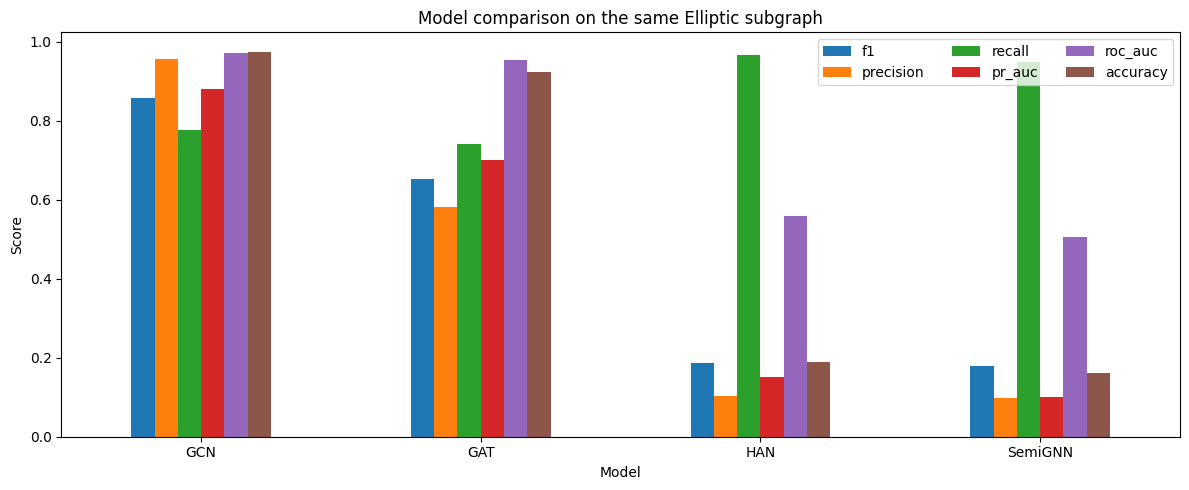

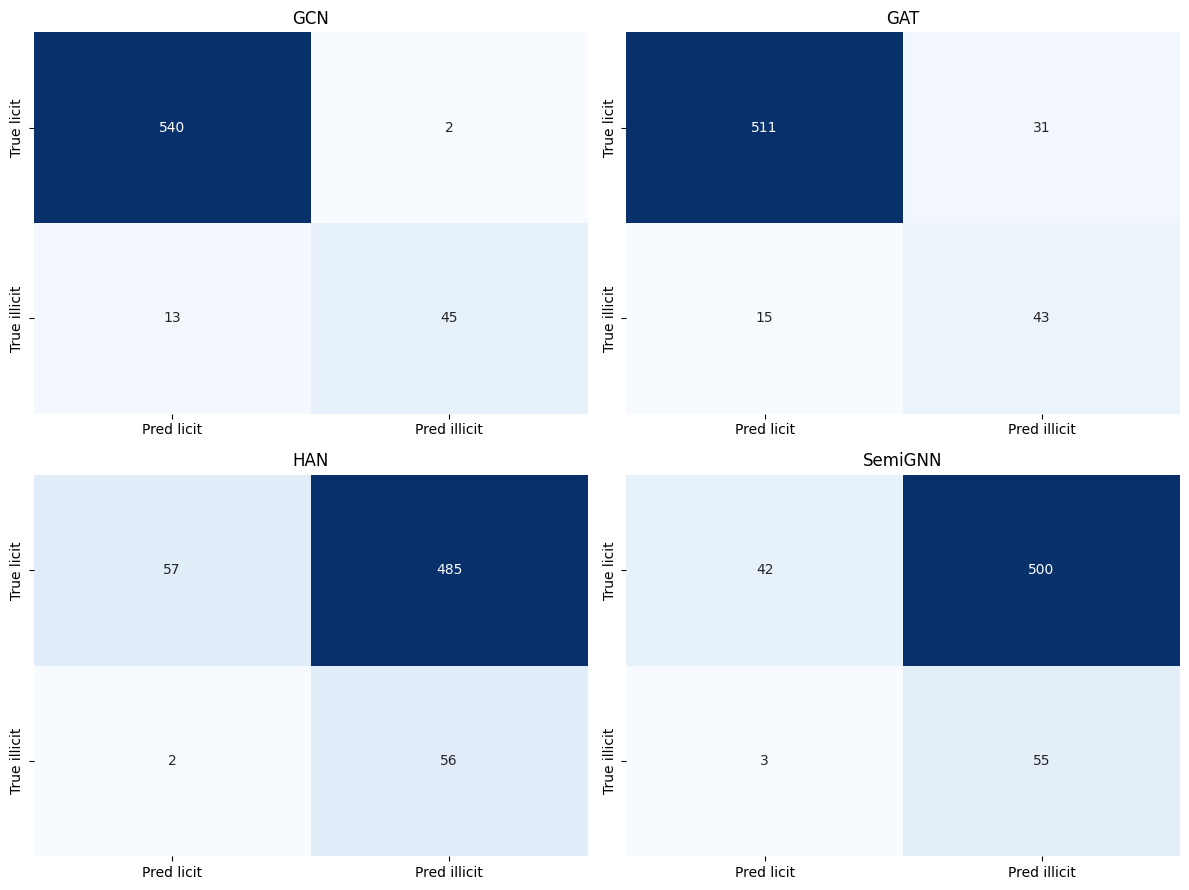

In [18]:
plot_model_comparison(results_df)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, row in zip(axes.ravel(), results_df.itertuples(index=False)):
    cm = np.array([[row.tn, row.fp], [row.fn, row.tp]])
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
        xticklabels=["Pred licit", "Pred illicit"],
        yticklabels=["True licit", "True illicit"],
    )
    ax.set_title(row.model)
plt.tight_layout()
plt.show()

In [19]:
best_f1_model = results_df.iloc[0]["model"]
best_precision_model = results_df.sort_values("precision", ascending=False).iloc[0]["model"]
best_recall_model = results_df.sort_values("recall", ascending=False).iloc[0]["model"]
best_pr_model = results_df.sort_values("pr_auc", ascending=False).iloc[0]["model"]

print("Best model by fraud F1:", best_f1_model)
print("Best model by precision:", best_precision_model)
print("Best model by recall:", best_recall_model)
print("Best model by PR-AUC:", best_pr_model)

Best model by fraud F1: GCN
Best model by precision: GCN
Best model by recall: HAN
Best model by PR-AUC: GCN
